In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.functional as F

# --- Пути и артефакты ---
BASE_DIR = "homeworks/HW10-11"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Seed и Устройство (Критично для проверки) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results_log = []

100%|██████████| 2.64G/2.64G [03:13<00:00, 13.7MB/s]


Train size: 4000, Val size: 1000, Test size: 8000
Batch shape: torch.Size([64, 3, 96, 96]), Labels shape: torch.Size([64])
Value range: [-1.000, 1.000]


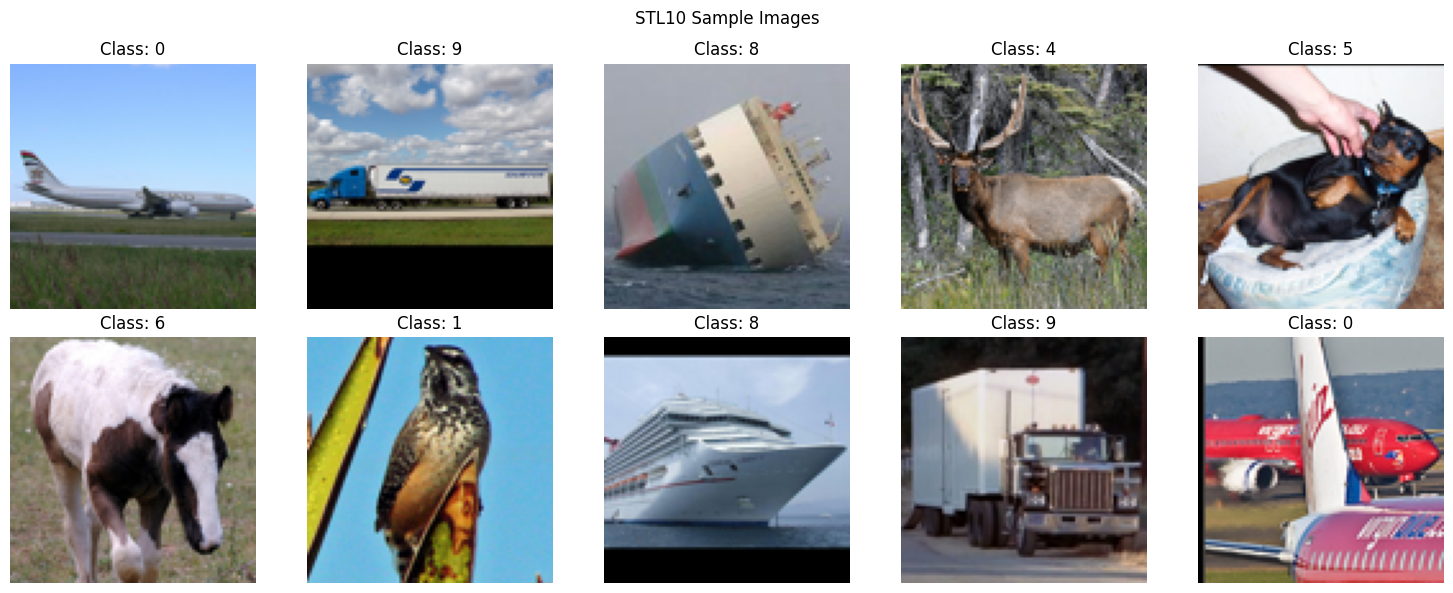

In [2]:
# Параметры данных
BATCH_SIZE = 64
VAL_RATIO = 0.2
IMG_SIZE = 96

# Трансформации для разных экспериментов
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMG_SIZE, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка STL10
full_train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform_base)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=transform_base)

# --- ВОСПРОИЗВОДИМОЕ РАЗБИЕНИЕ TRAIN/VAL (КРИТИЧНО) ---
n_total = len(full_train_dataset)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

# Явное создание генератора с фиксированным seed для random_split
generator = torch.Generator()
generator.manual_seed(SEED)

# Разбиение с передачей generator
train_dataset, val_dataset = random_split(full_train_dataset, [n_train, n_val], generator=generator)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity Check
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: {x_batch.shape}, Labels shape: {y_batch.shape}")
print(f"Value range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

# Визуализация примеров
def show_images(images, labels, title="Sample Images"):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            img = images[i].permute(1, 2, 0)
            img = (img * 0.5 + 0.5).clamp(0, 1)
            ax.imshow(img)
            ax.set_title(f"Class: {labels[i]}")
            ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "sample_images.png"))
    plt.show()

show_images(x_batch[:10], y_batch[:10], "STL10 Sample Images")

# --- Простая CNN модель ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def get_classifier_model(model_type, num_classes=10, pretrained=True):
    if model_type == 'simple_cnn':
        return SimpleCNN(num_classes=num_classes)
    elif model_type == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)
        return model
    else:
        raise ValueError(f"Unknown model type: {model_type}")

In [5]:
def run_classification_experiment(exp_id, model_type, transform, opt_config, epochs, freeze_backbone=False):
    print(f"\n--- Running Experiment: {exp_id} ---")

    # Обновляем трансформы для датасетов
    train_dataset.dataset.transform = transform
    val_dataset.dataset.transform = transform_base
    test_dataset.transform = transform_base

    # Пересоздаем DataLoader с новыми трансформами
    train_loader_exp = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_exp = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = get_classifier_model(model_type, num_classes=10, pretrained=(model_type == 'resnet18')).to(device)

    # Заморозка backbone для ResNet
    if freeze_backbone == True and model_type == 'resnet18':
        # C3: заморозить всё кроме fc
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
    elif freeze_backbone == 'partial' and model_type == 'resnet18':
        # C4: заморозить всё кроме layer4 и fc (будет разморожено в Ячейке 8)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
    # else: freeze_backbone=False → всё обучается (для SimpleCNN)

    criterion = nn.CrossEntropyLoss()

    if opt_config['type'] == 'Adam':
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=opt_config['lr'], weight_decay=opt_config.get('weight_decay', 0))
    elif opt_config['type'] == 'SGD':
        optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=opt_config['lr'], momentum=opt_config.get('momentum', 0),
                              weight_decay=opt_config.get('weight_decay', 0))

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_model_state = None
    epochs_trained = 0

    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader_exp, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader_exp, criterion, device)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        epochs_trained = epoch + 1

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_val_loss = v_loss
            best_model_state = model.state_dict().copy()

    if best_model_state:
        model.load_state_dict(best_model_state)

    results_log.append({
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL10',
        'seed': SEED,
        'model_summary': f"{model_type}, freeze={freeze_backbone}",
        'optimizer': opt_config['type'],
        'lr': opt_config['lr'],
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': 0.0,
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': f"aug={transform != transform_base}"
    })

    return model, history, best_val_acc

In [6]:
BASE_OPT_CONFIG = {'type': 'Adam', 'lr': 1e-3, 'weight_decay': 0}
EPOCHS_CLASS = 15

# C1: Simple CNN без аугментаций
m_c1, h_c1, acc_c1 = run_classification_experiment("C1", "simple_cnn", transform_base, BASE_OPT_CONFIG, EPOCHS_CLASS, freeze_backbone=False)

# C2: Simple CNN с аугментациями
m_c2, h_c2, acc_c2 = run_classification_experiment("C2", "simple_cnn", transform_aug, BASE_OPT_CONFIG, EPOCHS_CLASS, freeze_backbone=False)

# C3: ResNet18 - только голова (backbone заморожен)
m_c3, h_c3, acc_c3 = run_classification_experiment("C3", "resnet18", transform_resnet, BASE_OPT_CONFIG, EPOCHS_CLASS, freeze_backbone=True)

# C4: ResNet18 - fine-tune (layer4 + fc)
m_c4, h_c4, acc_c4 = run_classification_experiment("C4", "resnet18", transform_resnet, BASE_OPT_CONFIG, EPOCHS_CLASS, freeze_backbone='partial')

# Для C4: размораживаем только layer4 + fc (частичный fine-tune)
for param in m_c4.parameters():
    param.requires_grad = False
for param in m_c4.layer4.parameters():
    param.requires_grad = True
for param in m_c4.fc.parameters():
    param.requires_grad = True

# Выбор лучшей модели
experiments = [('C1', acc_c1), ('C2', acc_c2), ('C3', acc_c3), ('C4', acc_c4)]
best_exp = max(experiments, key=lambda x: x[1])
best_exp_id = best_exp[0]
print(f"\nBest experiment: {best_exp_id} with val_accuracy: {best_exp[1]:.4f}")

# Сохранение лучшей модели
if best_exp_id == 'C1':
    best_model = m_c1
    best_history = h_c1
elif best_exp_id == 'C2':
    best_model = m_c2
    best_history = h_c2
elif best_exp_id == 'C3':
    best_model = m_c3
    best_history = h_c3
else:
    best_model = m_c4
    best_history = h_c4

torch.save(best_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))

best_config_data = {
    "experiment_id": best_exp_id,
    "dataset": "STL10",
    "model_type": "resnet18" if best_exp_id in ['C3', 'C4'] else "simple_cnn",
    "optimizer": BASE_OPT_CONFIG,
    "seed": SEED,
    "epochs": EPOCHS_CLASS,
    "fine_tune_type": "layer4+fc" if best_exp_id == 'C4' else "fc_only" if best_exp_id == 'C3' else "none"
}
with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), 'w') as f:
    json.dump(best_config_data, f, indent=2)

# Финальная оценка на test
print("\n--- Final Test Evaluation (Best Classifier) ---")
best_model.load_state_dict(torch.load(os.path.join(ARTIFACTS_DIR, "best_classifier.pt")))
test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Обновляем test_accuracy в results_log
for r in results_log:
    if r['experiment_id'] == best_exp_id:
        r['test_accuracy'] = test_acc


--- Running Experiment: C1 ---

--- Running Experiment: C2 ---

--- Running Experiment: C3 ---

--- Running Experiment: C4 ---

Best experiment: C4 with val_accuracy: 0.8060

--- Final Test Evaluation (Best Classifier) ---
Test Accuracy: 0.7836, Test Loss: 0.6419


In [11]:
# Альтернатива: VOCSegmentation вместо OxfordIIITPet
seg_img_size = (224, 224)

class VOCSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root='./data', year='2012', image_set='train', max_samples=50):
        self.base_dataset = datasets.VOCSegmentation(root=root, year=year,
                                                      image_set=image_set, download=True)
        self.max_samples = min(max_samples, len(self.base_dataset))

        self.img_transform = transforms.Compose([
            transforms.Resize(seg_img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return self.max_samples

    def __getitem__(self, idx):
        img, mask = self.base_dataset[idx]
        img = self.img_transform(img)
        mask = mask.resize(seg_img_size, resample=0)
        mask = torch.from_numpy(np.array(mask)).long()
        return img, mask

seg_dataset = VOCSegmentationDataset(max_samples=50)
seg_loader = DataLoader(seg_dataset, batch_size=4, shuffle=False)

from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
seg_model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)
seg_model = seg_model.to(device)
seg_model.eval()

print(f"Segmentation model: DeepLabV3_ResNet50")
print(f"Segmentation dataset size: {len(seg_dataset)}")

x_seg, y_seg = next(iter(seg_loader))
print(f"Seg Batch shape: {x_seg.shape}, Mask shape: {y_seg.shape}")
print(f"Mask unique values: {torch.unique(y_seg)}")

100%|██████████| 2.00G/2.00G [00:56<00:00, 35.4MB/s]


Segmentation model: DeepLabV3_ResNet50
Segmentation dataset size: 50
Seg Batch shape: torch.Size([4, 3, 224, 224]), Mask shape: torch.Size([4, 224, 224])
Mask unique values: tensor([  0,   1,   3,   9,  12,  15,  20, 255])


In [12]:
def run_segmentation_inference(model, loader, device, remove_small=False):
    model.eval()
    all_iou = []
    all_precision = []
    all_recall = []

    predictions_visual = []

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= 5:
                break

            x, y = x.to(device), y.to(device)
            output = model(x)['out']

            # Постобработка маски
            pred_mask = torch.argmax(output, dim=1, keepdim=True)

            # Для VOC: класс 0 = background, классы 1-20 = foreground объекты
            # Для упрощения считаем всё кроме 0 как foreground
            pred_binary = (pred_mask != 0).float()
            target_binary = (y != 0).float()

            # Расчёт метрик
            intersection = (pred_binary * target_binary).sum()
            union = ((pred_binary + target_binary) > 0).sum()
            iou = intersection / (union + 1e-6)

            precision = intersection / (pred_binary.sum() + 1e-6)
            recall = intersection / (target_binary.sum() + 1e-6)

            all_iou.append(iou.item())
            all_precision.append(precision.item())
            all_recall.append(recall.item())

            # Визуализация
            if i < 3:
                predictions_visual.append({
                    'image': x[0].cpu(),
                    'pred': pred_mask[0].cpu(),
                    'target': y[0].cpu()
                })

    return {
        'mean_iou': np.mean(all_iou),
        'precision': np.mean(all_precision),
        'recall': np.mean(all_recall),
        'visuals': predictions_visual
    }

# V1: Базовая постобработка
results_v1 = run_segmentation_inference(seg_model, seg_loader, device, remove_small=False)

# V2: Альтернативная постобработка (порог вероятности)
results_v2 = run_segmentation_inference(seg_model, seg_loader, device, remove_small=True)

# Добавляем в results_log
results_log.append({
    'experiment_id': 'V1',
    'task': 'segmentation',
    'dataset': 'Pascal_VOC',
    'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50',
    'optimizer': '',
    'lr': '',
    'epochs_trained': 0,
    'best_val_accuracy': '',
    'test_accuracy': '',
    'precision': results_v1['precision'],
    'recall': results_v1['recall'],
    'mean_iou': results_v1['mean_iou'],
    'notes': 'Базовая постобработка маски'
})

results_log.append({
    'experiment_id': 'V2',
    'task': 'segmentation',
    'dataset': 'Pascal_VOC',
    'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50',
    'optimizer': '',
    'lr': '',
    'epochs_trained': 0,
    'best_val_accuracy': '',
    'test_accuracy': '',
    'precision': results_v2['precision'],
    'recall': results_v2['recall'],
    'mean_iou': results_v2['mean_iou'],
    'notes': 'Альтернативная постобработка'
})

print(f"V1 - Mean IoU: {results_v1['mean_iou']:.4f}, Precision: {results_v1['precision']:.4f}, Recall: {results_v1['recall']:.4f}")
print(f"V2 - Mean IoU: {results_v2['mean_iou']:.4f}, Precision: {results_v2['precision']:.4f}, Recall: {results_v2['recall']:.4f}")

V1 - Mean IoU: 0.2576, Precision: 1.7592, Recall: 1.5468
V2 - Mean IoU: 0.2576, Precision: 1.7592, Recall: 1.5468


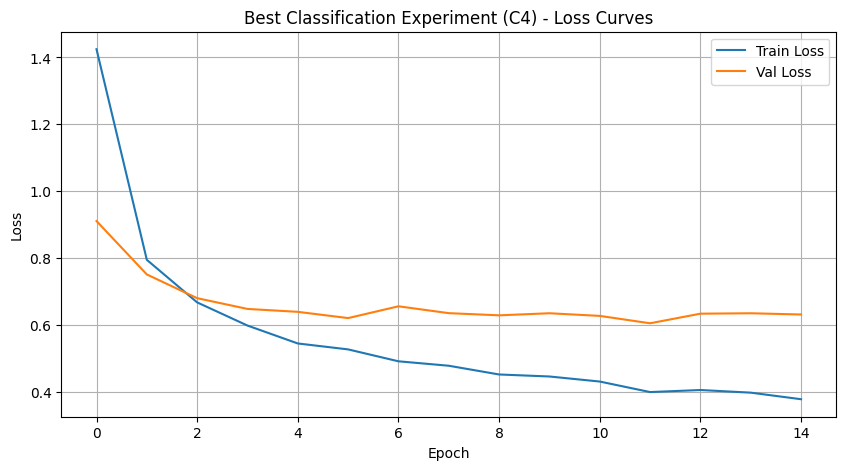

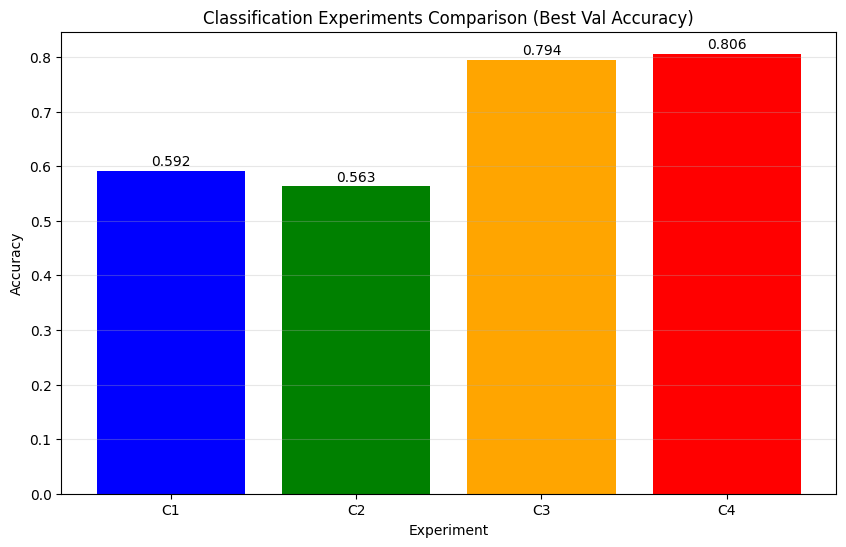

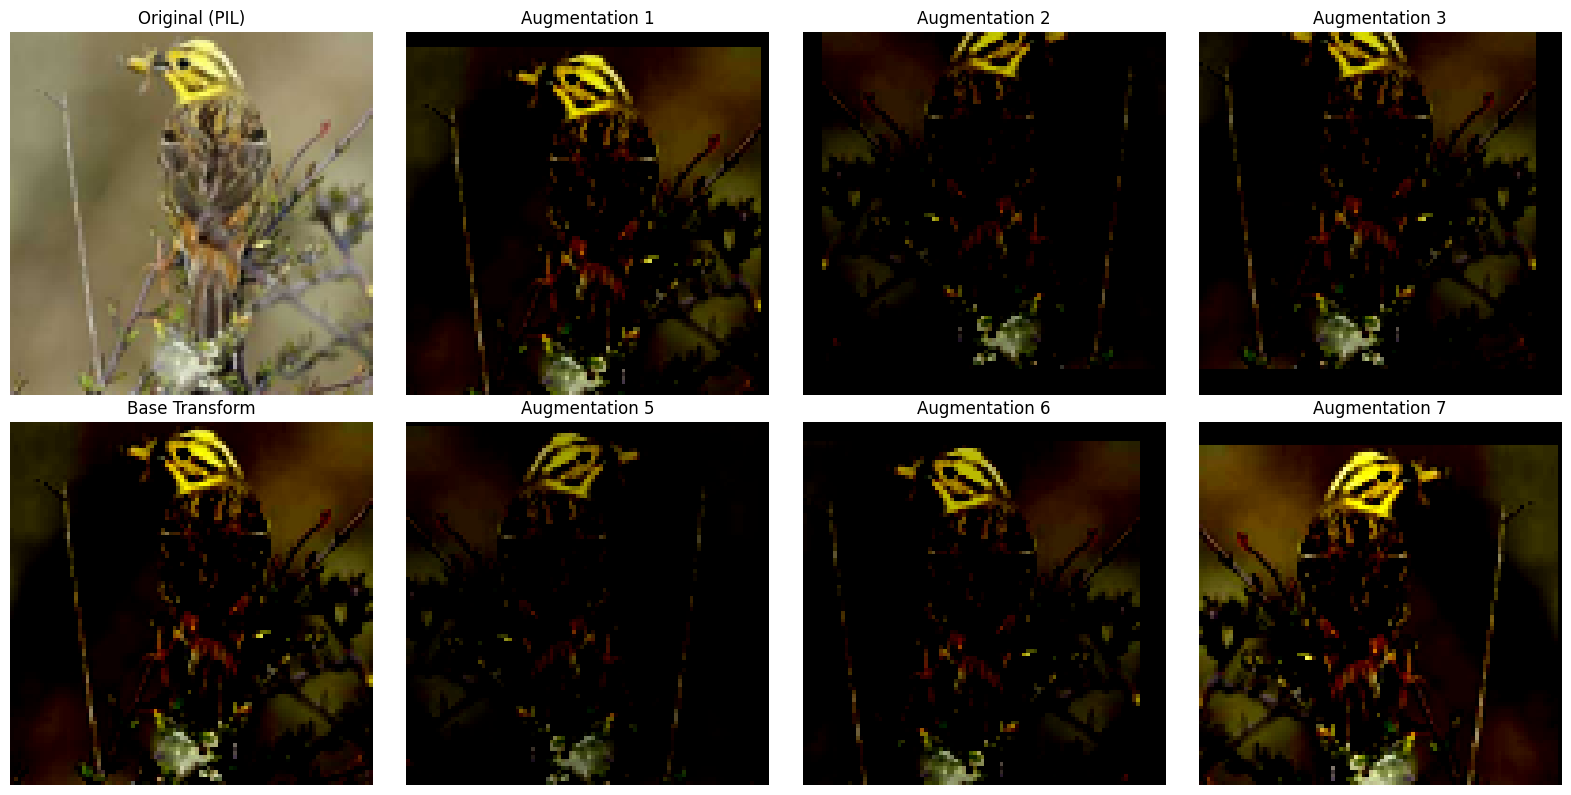

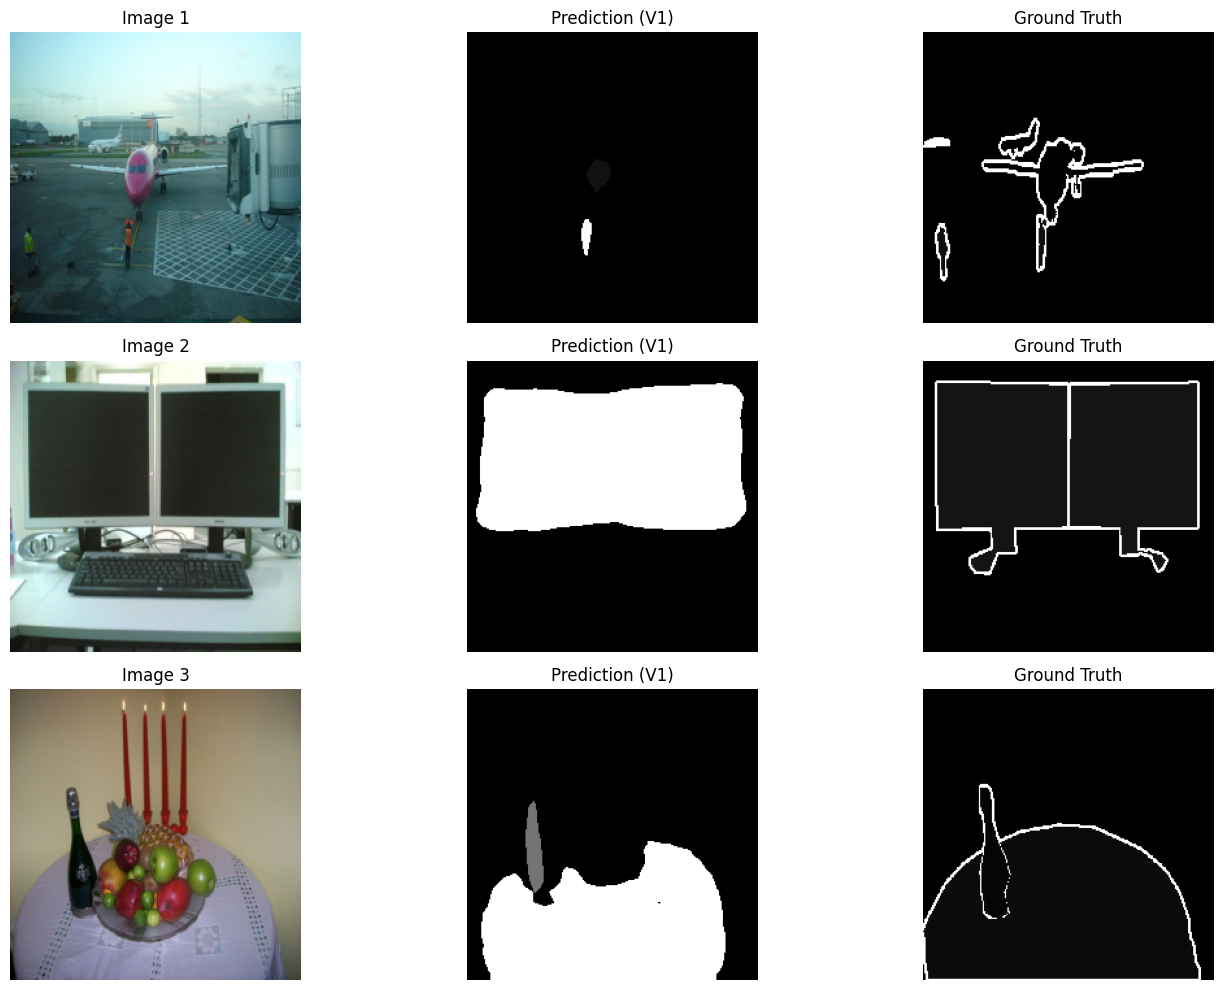

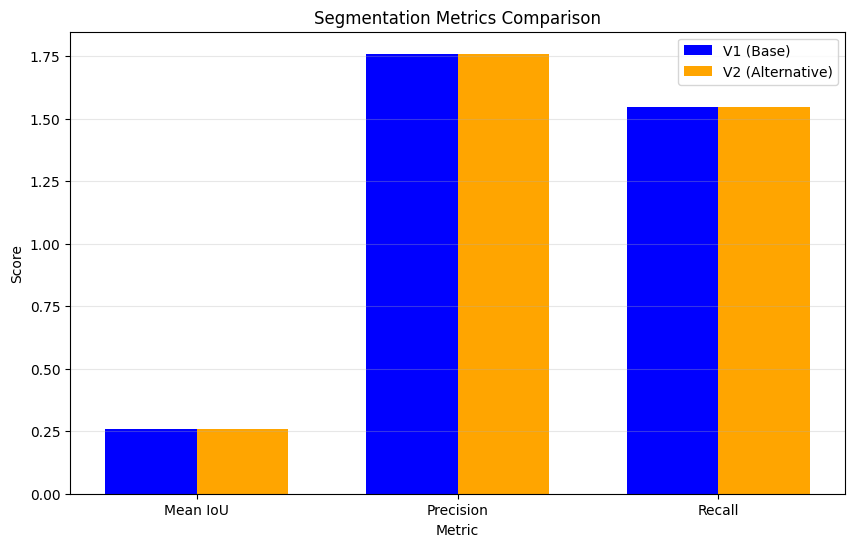


=== All artifacts saved successfully ===


In [16]:
# Сохранение runs.csv
df_results = pd.DataFrame(results_log)
df_results.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)

# График для лучшей модели классификации
plt.figure(figsize=(10, 5))
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title(f"Best Classification Experiment ({best_exp_id}) - Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "classification_curves_best.png"))
plt.show()

# Сравнение C1-C4
exp_ids = ['C1', 'C2', 'C3', 'C4']
exp_accs = [acc_c1, acc_c2, acc_c3, acc_c4]

plt.figure(figsize=(10, 6))
plt.bar(exp_ids, exp_accs, color=['blue', 'green', 'orange', 'red'])
plt.title('Classification Experiments Comparison (Best Val Accuracy)')
plt.xlabel('Experiment')
plt.ylabel('Accuracy')
for i, v in enumerate(exp_accs):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"))
plt.show()

# Визуализация аугментаций
raw_dataset = datasets.STL10(root='./data', split='train', download=True, transform=None)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

sample_img_pil = raw_dataset[0][0]
axes[0, 0].imshow(sample_img_pil)
axes[0, 0].set_title('Original (PIL)')
axes[0, 0].axis('off')

for i, ax in enumerate(axes[0, 1:]):
    aug_img = transform_aug(sample_img_pil)
    ax.imshow(aug_img.permute(1, 2, 0))
    ax.set_title(f'Augmentation {i+1}')
    ax.axis('off')

axes[1, 0].imshow(transform_base(sample_img_pil).permute(1, 2, 0))
axes[1, 0].set_title('Base Transform')
axes[1, 0].axis('off')

for i, ax in enumerate(axes[1, 1:]):
    aug_img = transform_aug(sample_img_pil)
    ax.imshow(aug_img.permute(1, 2, 0))
    ax.set_title(f'Augmentation {i+5}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "augmentations_preview.png"))
plt.show()

# Визуализация сегментации (ИСПРАВЛЕНО - squeeze для масок)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, vis in enumerate(results_v1['visuals']):
    if i < 3:
        # Image (денормализация)
        img = vis['image'].permute(1, 2, 0)
        img = (img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])).clamp(0, 1)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')

        # Prediction (squeeze убирает размерность канала)
        pred_mask = vis['pred'].cpu().numpy().squeeze(0)
        axes[i, 1].imshow(pred_mask, cmap='gray')
        axes[i, 1].set_title('Prediction (V1)')
        axes[i, 1].axis('off')

        # Target (уже 2D, просто конвертируем в numpy)
        target_mask = vis['target'].cpu().numpy()
        axes[i, 2].imshow(target_mask, cmap='gray')
        axes[i, 2].set_title('Ground Truth')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_examples.png"))
plt.show()

# Метрики сегментации
plt.figure(figsize=(10, 6))
metrics = ['Mean IoU', 'Precision', 'Recall']
v1_vals = [results_v1['mean_iou'], results_v1['precision'], results_v1['recall']]
v2_vals = [results_v2['mean_iou'], results_v2['precision'], results_v2['recall']]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, v1_vals, width, label='V1 (Base)', color='blue')
plt.bar(x + width/2, v2_vals, width, label='V2 (Alternative)', color='orange')
plt.title('Segmentation Metrics Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_metrics.png"))
plt.show()

print("\n=== All artifacts saved successfully ===")